In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dt=pd.read_csv("Titanic-Dataset.csv")

In [3]:
dt.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
824,825,0,3,"Panula, Master. Urho Abraham",male,2.0,4,1,3101295,39.6875,NaN,S
547,548,1,2,"Padro y Manent, Mr. Julian",male,NaN,0,0,SC/PARIS 2146,13.8625,NaN,C
450,451,0,2,"West, Mr. Edwy Arthur",male,36.0,1,2,C.A. 34651,27.7500,NaN,S
769,770,0,3,"Gronnestad, Mr. Daniel Danielsen",male,32.0,0,0,8471,8.3625,NaN,S
431,432,1,3,"Thorneycroft, Mrs. Percival (Florence Kate White)",female,NaN,1,0,376564,16.1000,NaN,S


In [4]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
dt.drop(columns=['PassengerId','Cabin'],axis=1,inplace=True)

In [6]:
dt.sample(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
88,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S
751,1,3,"Moor, Master. Meier",male,6.0,0,1,392096,12.4750,S
371,0,3,"Wiklund, Mr. Jakob Alfred",male,18.0,1,0,3101267,6.4958,S
807,0,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,347087,7.7750,S
539,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5000,C


In [7]:
dt.shape

(891, 10)

In [8]:
dt.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [9]:
dt.loc[dt['Age'] >0,'Age'].mean()

np.float64(29.69911764705882)

In [10]:
dt['Age']=dt['Age'].fillna(dt['Age'].mean())

In [11]:
dt.dropna(inplace=True)

In [12]:
dt.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [13]:
dt.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.653446,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.968366,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
dt.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')

| Column       | What it Means                                                  | Example                                                  |
| ------------ | -------------------------------------------------------------- | -------------------------------------------------------- |
| **Survived** | Did the passenger survive? (Target column)                     | `1 = Yes`, `0 = No`                                      |
| **Pclass**   | Passenger's ticket class (social/economic status)              | `1 = First Class`, `2 = Second Class`, `3 = Third Class` |
| **Name**     | Passenger's full name                                          | `"Allen, Mr. William Henry"`                             |
| **Sex**      | Gender of the passenger                                        | `male`, `female`                                         |
| **Age**      | Passenger's age in years                                       | `22`, `38`, `5`                                          |
| **SibSp**    | Number of **siblings or spouses** traveling with the passenger | `1`, `0`, `2`                                            |
| **Parch**    | Number of **parents or children** traveling with the passenger | `0`, `1`, `3`                                            |
| **Ticket**   | Ticket number                                                  | `A/5 21171`                                              |
| **Fare**     | Amount paid for the ticket                                     | `7.25`, `71.28`                                          |
| **Embarked** | Port where the passenger boarded the Titanic                   | `C`, `Q`, `S`                                            |


In [15]:
dt.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [16]:
dt.rename(columns={'Sex':'Gender'},inplace=True)


In [17]:
# dt['Ticket'].nunique()

In [18]:
# dt['Ticket_Number'] = dt['Ticket'].str.extract(r'(\d+)')

In [19]:
dt.drop(columns='Ticket',inplace=True)

In [20]:
# dt['Ticket_Number'] = pd.to_numeric(dt['Ticket_Number'])

In [21]:
dt.sample()

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Fare,Embarked
751,1,3,"Moor, Master. Meier",male,6.0,0,1,12.475,S


In [22]:
dt.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.335549,-0.074673,-0.034040,0.083151,0.255290
Pclass,-0.335549,1.000000,-0.327954,0.081656,0.016824,-0.548193
Age,-0.074673,-0.327954,1.000000,-0.231875,-0.178232,0.088604
SibSp,-0.034040,0.081656,-0.231875,1.000000,0.414542,0.160887
Parch,0.083151,0.016824,-0.178232,0.414542,1.000000,0.217532
Fare,0.255290,-0.548193,0.088604,0.160887,0.217532,1.000000


In [23]:
data=dt.copy()

### Label Encoding

In [24]:
data['Gender']=data['Gender'].map({
    'male':1,
    'female':0

})

| Code  | Port                  | Country |
| ----- | --------------------- | ------- |
| **S** | Southampton           | England |
| **C** | Cherbourg             | France  |
| **Q** | Queenstown (now Cobh) | Ireland |


In [25]:
from sklearn.preprocessing import LabelEncoder
encoding=LabelEncoder()
data['Embarked']=encoding.fit_transform(data['Embarked']) #C = 0   Q = 1 S = 2

<Axes: xlabel='Embarked', ylabel='count'>

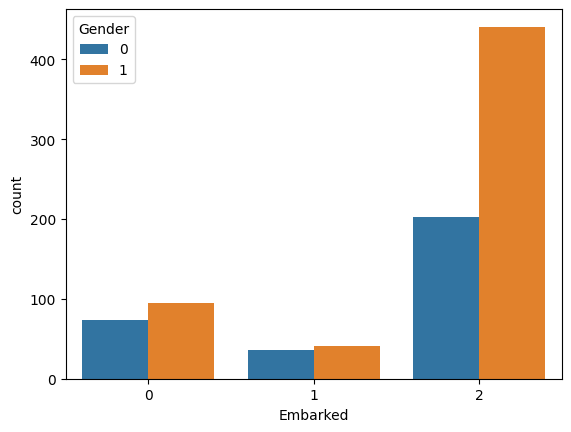

In [26]:
sns.countplot(data,x=data['Embarked'],hue='Gender')

In [27]:
data['Family']=data['SibSp'] + data['Parch']

In [28]:
data.corr(numeric_only=True)

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked,Family
Survived,1.000000,-0.335549,-0.541585,-0.074673,-0.034040,0.083151,0.255290,-0.169718,0.018277
Pclass,-0.335549,1.000000,0.127741,-0.327954,0.081656,0.016824,-0.548193,0.164681,0.064221
Gender,-0.541585,0.127741,1.000000,0.089434,-0.116348,-0.247508,-0.179958,0.110320,-0.203191
Age,-0.074673,-0.327954,0.089434,1.000000,-0.231875,-0.178232,0.088604,-0.028927,-0.247546
SibSp,-0.034040,0.081656,-0.116348,-0.231875,1.000000,0.414542,0.160887,0.068900,0.890654
Parch,0.083151,0.016824,-0.247508,-0.178232,0.414542,1.000000,0.217532,0.040449,0.782988
Fare,0.255290,-0.548193,-0.179958,0.088604,0.160887,0.217532,1.000000,-0.226311,0.218658
Embarked,-0.169718,0.164681,0.110320,-0.028927,0.068900,0.040449,-0.226311,1.000000,0.067305
Family,0.018277,0.064221,-0.203191,-0.247546,0.890654,0.782988,0.218658,0.067305,1.000000


In [29]:
pd.crosstab(data['Gender'],data['Survived'])

Survived,0,1
Gender,,
0,81,231
1,468,109


In [30]:
pd.crosstab(data['Embarked'],data['Survived'])

Survived,0,1
Embarked,,
0,75,93
1,47,30
2,427,217


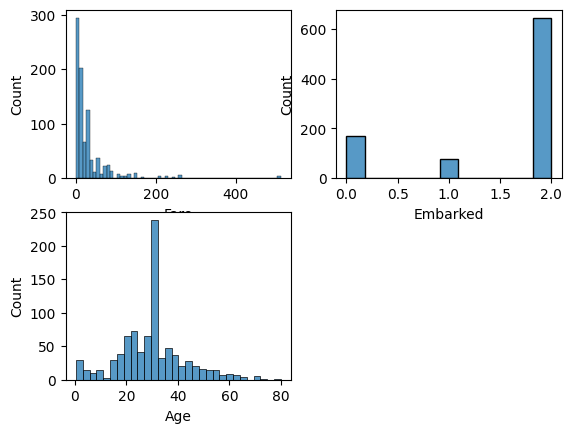

In [31]:
def vis(value,x):
    plt.subplot(2,2,x)
    sns.histplot(x=data[value])
vis('Fare',1)
vis('Embarked',2)
vis('Age',3)

<Axes: ylabel='Fare'>

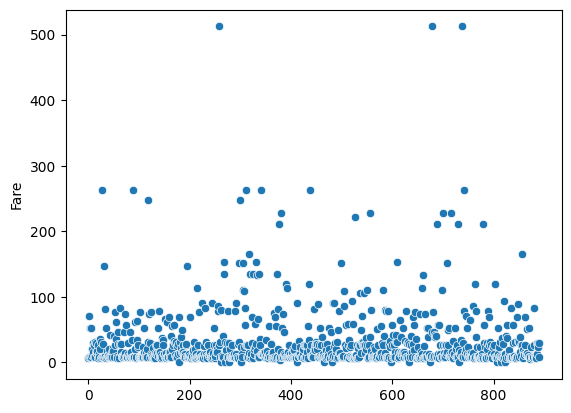

In [32]:
sns.scatterplot(data['Fare'])

In [33]:
data.sample(5)

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Fare,Embarked,Family
275,1,1,"Andrews, Miss. Kornelia Theodosia",0,63.0,1,0,77.9583,2,1
514,0,3,"Coleff, Mr. Satio",1,24.0,0,0,7.4958,2,0
548,0,3,"Goldsmith, Mr. Frank John",1,33.0,1,1,20.5250,2,2
714,0,2,"Greenberg, Mr. Samuel",1,52.0,0,0,13.0000,2,0
401,0,3,"Adams, Mr. John",1,26.0,0,0,8.0500,2,0


In [34]:
data[data['Pclass'] == 1]

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Fare,Embarked,Family
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2,1
6,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,51.8625,2,0
11,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,26.5500,2,0
23,1,1,"Sloper, Mr. William Thompson",1,28.0,0,0,35.5000,2,0
...,...,...,...,...,...,...,...,...,...,...
871,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",0,47.0,1,1,52.5542,2,2
872,0,1,"Carlsson, Mr. Frans Olof",1,33.0,0,0,5.0000,2,0
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",0,56.0,0,1,83.1583,0,1
887,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,30.0000,2,0


In [35]:
pd.crosstab(data['Pclass'],data['Embarked'])

Embarked,0,1,2
Pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


In [36]:
data.drop(columns=['SibSp','Parch'])

,Survived,Pclass,Name,Gender,Age,Fare,Embarked,Family
0,0,3,"Braund, Mr. Owen Harris",1,22.000000,7.2500,2,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,71.2833,0,1
2,1,3,"Heikkinen, Miss. Laina",0,26.000000,7.9250,2,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,53.1000,2,1
4,0,3,"Allen, Mr. William Henry",1,35.000000,8.0500,2,0
...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",1,27.000000,13.0000,2,0
887,1,1,"Graham, Miss. Margaret Edith",0,19.000000,30.0000,2,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,23.4500,2,3
889,1,1,"Behr, Mr. Karl Howell",1,26.000000,30.0000,0,0


In [37]:
data.groupby('Embarked')['Gender'].agg([
    'min','max','mean','median','count'
]).sort_values('max',ascending=False).round(0)

,min,max,mean,median,count
Embarked,,,,,
0,0,1,1.0,1.0,168
1,0,1,1.0,1.0,77
2,0,1,1.0,1.0,644


In [38]:
pd.crosstab(data['Pclass'] , data['Survived'] ,normalize='index')*100

Survived,0,1
Pclass,,
1,37.383178,62.616822
2,52.717391,47.282609
3,75.763747,24.236253


In [39]:
data.groupby('Pclass')['Survived'].count()

Pclass
1    214
2    184
3    491
Name: Survived, dtype: int64

In [40]:
data.groupby('Embarked')['Fare'].sum()

Embarked
0    10072.2962
1     1022.2543
2    17439.3988
Name: Fare, dtype: float64

In [41]:
data.sample(4)

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Fare,Embarked,Family
136,1,1,"Newsom, Miss. Helen Monypeny",0,19.000000,0,2,26.2833,2,2
549,1,2,"Davies, Master. John Morgan Jr",1,8.000000,1,1,36.7500,2,2
236,0,2,"Hold, Mr. Stephen",1,44.000000,1,0,26.0000,2,1
711,0,1,"Klaber, Mr. Herman",1,29.699118,0,0,26.5500,2,0


In [42]:
data["Age_category"]=pd.cut(
    data['Age'],
    bins=[0,13,19,35,60,100],
    labels=['Child','Teen','Adult','Senior','Old Senior'],
    
)

In [43]:
data.sample(5)

,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Fare,Embarked,Family,Age_category
63,0,3,"Skoog, Master. Harald",1,4.0,3,2,27.9000,2,5,Child
733,0,2,"Berriman, Mr. William John",1,23.0,0,0,13.0000,2,0,Adult
545,0,1,"Nicholson, Mr. Arthur Ernest",1,64.0,0,0,26.0000,2,0,Old Senior
329,1,1,"Hippach, Miss. Jean Gertrude",0,16.0,0,1,57.9792,0,1,Teen
690,1,1,"Dick, Mr. Albert Adrian",1,31.0,1,0,57.0000,2,1,Adult


In [44]:
age=data['Age_category'].value_counts()

<Axes: xlabel='Age_category', ylabel='count'>

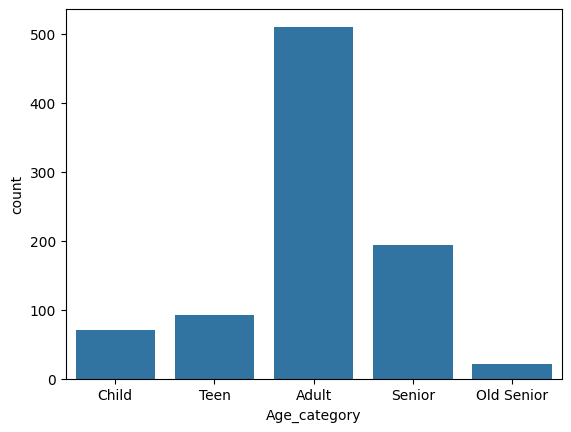

In [45]:
sns.countplot(x=data['Age_category'])

In [46]:
pd.crosstab(data['Age_category'],data['Survived'])

Survived,0,1
Age_category,,
Child,29,42
Teen,56,37
Adult,330,180
Senior,117,77
Old Senior,17,4


<Axes: xlabel='Pclass', ylabel='count'>

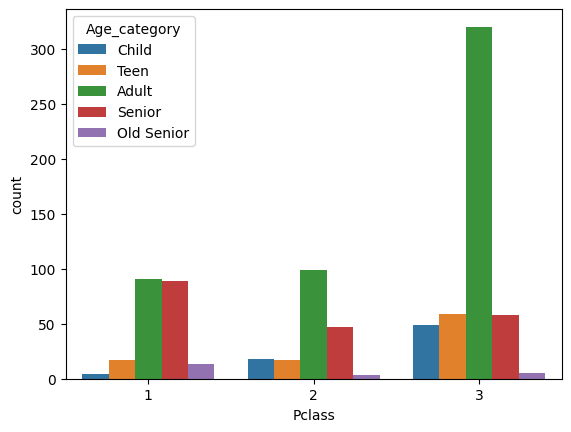

In [47]:
sns.countplot(data=data,x=data['Pclass'],hue='Age_category')

In [48]:
data['Age_category'].value_counts()

Age_category
Adult         510
Senior        194
Teen           93
Child          71
Old Senior     21
Name: count, dtype: int64

In [49]:
data['Age_category']=data['Age_category'].map({
    'Child':0,
    'Teen':1,
    'Adult':3,
    'Senior':4,
    'Old Senior':5
    
})

In [50]:
data['Age_category']=data['Age_category'].astype(int)

In [51]:
data.corr(numeric_only=True)

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked,Family,Age_category
Survived,1.000000,-0.335549,-0.541585,-0.074673,-0.034040,0.083151,0.255290,-0.169718,0.018277,-0.102418
Pclass,-0.335549,1.000000,0.127741,-0.327954,0.081656,0.016824,-0.548193,0.164681,0.064221,-0.243835
Gender,-0.541585,0.127741,1.000000,0.089434,-0.116348,-0.247508,-0.179958,0.110320,-0.203191,0.106534
Age,-0.074673,-0.327954,0.089434,1.000000,-0.231875,-0.178232,0.088604,-0.028927,-0.247546,0.877578
SibSp,-0.034040,0.081656,-0.116348,-0.231875,1.000000,0.414542,0.160887,0.068900,0.890654,-0.284098
Parch,0.083151,0.016824,-0.247508,-0.178232,0.414542,1.000000,0.217532,0.040449,0.782988,-0.232877
Fare,0.255290,-0.548193,-0.179958,0.088604,0.160887,0.217532,1.000000,-0.226311,0.218658,0.053498
Embarked,-0.169718,0.164681,0.110320,-0.028927,0.068900,0.040449,-0.226311,1.000000,0.067305,-0.017580
Family,0.018277,0.064221,-0.203191,-0.247546,0.890654,0.782988,0.218658,0.067305,1.000000,-0.310544
Age_category,-0.102418,-0.243835,0.106534,0.877578,-0.284098,-0.232877,0.053498,-0.017580,-0.310544,1.000000


In [52]:
data[['Age','Pclass']].describe()

,Age,Pclass
count,889.000000,889.000000
mean,29.653446,2.311586
std,12.968366,0.834700
min,0.420000,1.000000
25%,22.000000,2.000000
50%,29.699118,3.000000
75%,35.000000,3.000000
max,80.000000,3.000000


In [53]:
data.drop(columns=['Name'],axis=1,inplace=True)

In [54]:
#Model Implemnetation

**Models Implementation **

In [55]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score

In [56]:
data.columns

Index(['Survived', 'Pclass', 'Gender', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Family', 'Age_category'],
      dtype='object')

In [84]:

x=data.drop(columns=['Survived','Age_category','SibSp','Parch','Family'],axis=1)
y=data['Survived']
x


,Pclass,Gender,Age,Fare,Embarked
0,3,1,22,7,2
1,1,0,38,71,0
2,3,0,26,7,2
3,1,0,35,53,2
4,3,1,35,8,2
...,...,...,...,...,...
886,2,1,27,13,2
887,1,0,19,30,2
888,3,0,29,23,2
889,1,1,26,30,0


In [71]:
data['Age']=data['Age'].astype(int)
data['Fare']=data['Fare'].astype(int)

In [72]:
# x=data.drop(columns='Survived',axis=1)
# y=data['Survived']

In [85]:
columns=['Pclass', 'Gender', 'Age','Fare','Embarked']
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train[columns]=scaler.fit_transform(x_train[columns])
x_test[columns]=scaler.fit_transform(x_test[columns])


In [93]:
models={
    'Logistic Regression':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'NaivBair':GaussianNB(),
    'SVM':SVC(probability=True)
}

In [94]:
result=[]

In [95]:
for name ,model in models.items():
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  result.append({
      'Name':name,
      'Acc':round(acc,4),
      'f1_score':round(f1,4)
  })




In [96]:
result

[{'Name': 'Logistic Regression', 'Acc': 0.7809, 'f1_score': 0.7068},
 {'Name': 'KNN', 'Acc': 0.7978, 'f1_score': 0.75},
 {'Name': 'NaivBair', 'Acc': 0.7809, 'f1_score': 0.7068},
 {'Name': 'SVM', 'Acc': 0.8202, 'f1_score': 0.746}]

### SAving THe Model 

In [97]:
import joblib
joblib.dump(models['SVM'],'Titanic_Survival.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']

In [98]:
x.columns

Index(['Pclass', 'Gender', 'Age', 'Fare', 'Embarked'], dtype='object')